# Sequential Multi-Agent Architecture -- Blog Post Writing Pipeline

## Problem card

- **User/trigger:** a user gives a topic; the system must produce a publish-ready blog
  post.
- **Inputs:** a topic string (e.g. "Why vector databases matter for RAG").
- **Output:** a finished blog post with a title, intro, structured body, and conclusion,
  passed through research, outlining, drafting, and editing before it is returned.
- **Success criteria:** every stage's output is genuinely required as the next stage's
  input (you cannot outline before you have research, cannot write before you have an
  outline, cannot edit before you have a draft); each stage is owned by one agent with
  one narrow job and one system message; the final state carries every intermediate
  artifact, not just the last one, so the pipeline is auditable end to end.
- **Topology:** a **sequential multi-agent pipeline** -- four separate agents, each a
  distinct LangGraph node with its own system message, wired one after another in a
  fixed order. No agent revisits an earlier stage and no agent runs concurrently with
  another.

## Why sequential (not single-agent, not parallel)

A single agent with one system message asked to "research, outline, draft, and edit"
has to hold all four jobs' instructions and all four jobs' outputs in one context at
once, and nothing stops it from skipping a stage (writing straight from the topic,
skipping research) or blurring stages together (editing while it drafts). Splitting the
work into four agents, each with a **narrow, single-purpose system message**, forces
every stage to actually happen, makes each stage's prompt shorter and more reliable,
and makes the pipeline's intermediate state inspectable -- you can print the research
notes or the outline independently of the final post.

Parallel fan-out (covered in the companion notebook,
`parallel_fanout_fanin_orchestrator.ipynb`) is the wrong shape here because these four
jobs are **not independent** -- outlining genuinely needs the research, drafting
genuinely needs the outline. Sequential fits precisely when stage *N* cannot start
without stage *N-1*'s output; parallel fits when the branches don't depend on each
other at all.

## The four agents

| # | Agent | System message role | Reads | Writes |
|---|---|---|---|---|
| 1 | `researcher` | Gather concrete facts, angles, and talking points for the topic | `topic` | `research_notes` |
| 2 | `outliner` | Turn research into a structured heading/bullet outline | `topic`, `research_notes` | `outline` |
| 3 | `writer` | Expand the outline into full prose using the research as grounding | `topic`, `research_notes`, `outline` | `draft` |
| 4 | `editor` | Polish tone, clarity, and flow into a publish-ready post | `topic`, `draft` | `final_post` |

Each agent is invoked with **exactly its own `SystemMessage`** -- no agent ever sees
another agent's system prompt, and no agent's job overlaps another's. The only channel
between agents is the shared LangGraph state.


In [1]:
import os
import warnings
import logging
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.4)

print(f"Model: {OPENAI_MODEL}")


Model: gpt-4o-mini


## State

One `TypedDict` carries the topic plus every stage's output. Nothing is overwritten --
`research_notes`, `outline`, and `draft` all remain readable in the final state
alongside `final_post`, so the pipeline is auditable: you can see exactly what each
agent produced, not just the end result.


In [2]:
from typing import TypedDict


class BlogState(TypedDict, total=False):
    topic: str
    research_notes: str
    outline: str
    draft: str
    final_post: str


## Agent 1: `researcher`

Job: given only the topic, produce concrete, concise research notes -- facts, angles,
examples a writer could ground a post in. It does **not** know about outlining,
drafting, or editing; its system message says nothing about tone, structure, or length
of a finished post.


In [3]:
RESEARCHER_SYSTEM_PROMPT = (
    "You are a research agent. Given a blog topic, produce 5-8 concise, concrete "
    "research notes: real facts, angles, examples, or talking points a writer could "
    "use. Do not write any prose for the post itself -- only bullet-point research "
    "notes. Do not suggest a structure or outline; that is a different agent's job."
)


def researcher_node(state: BlogState) -> dict:
    messages = [
        SystemMessage(content=RESEARCHER_SYSTEM_PROMPT),
        HumanMessage(content=f"Topic: {state['topic']}"),
    ]
    response = llm.invoke(messages)
    return {"research_notes": response.content}


## Agent 2: `outliner`

Job: turn the topic + research notes into a structured outline (headings + bullets).
It does not write prose and does not do its own research -- it only reorganizes what
the researcher already produced.


In [4]:
OUTLINER_SYSTEM_PROMPT = (
    "You are an outlining agent. Given a blog topic and a set of research notes, "
    "produce a structured outline: a working title, then 3-5 section headings, each "
    "with 2-3 bullet points of what that section will cover. Use only the research "
    "notes provided -- do not invent new facts. Do not write full prose; only the "
    "outline."
)


def outliner_node(state: BlogState) -> dict:
    messages = [
        SystemMessage(content=OUTLINER_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Topic: {state['topic']}\n\n"
                f"Research notes:\n{state['research_notes']}"
            )
        ),
    ]
    response = llm.invoke(messages)
    return {"outline": response.content}


## Agent 3: `writer`

Job: expand the outline into a full first-draft blog post, grounded in the research
notes. It does not decide structure (that was the outliner's job) and does not polish
tone or fix flow issues (that is the editor's job) -- it drafts.


In [5]:
WRITER_SYSTEM_PROMPT = (
    "You are a drafting agent. Given a topic, research notes, and an approved outline, "
    "write a full first-draft blog post that follows the outline's structure exactly "
    "and uses the research notes as grounding. Write complete prose for every section "
    "in the outline. Do not change the outline's structure. Do not worry about final "
    "polish -- a later agent will edit this draft."
)


def writer_node(state: BlogState) -> dict:
    messages = [
        SystemMessage(content=WRITER_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Topic: {state['topic']}\n\n"
                f"Research notes:\n{state['research_notes']}\n\n"
                f"Outline:\n{state['outline']}"
            )
        ),
    ]
    response = llm.invoke(messages)
    return {"draft": response.content}


## Agent 4: `editor`

Job: polish the draft into a publish-ready post -- tighten prose, fix flow between
sections, sharpen the title. It does not do research, does not restructure the outline,
and does not add new claims -- only edits what the writer produced.


In [6]:
EDITOR_SYSTEM_PROMPT = (
    "You are an editing agent. Given a topic and a full draft blog post, edit it into "
    "a publish-ready final version: tighten prose, improve flow between sections, "
    "sharpen the title, and fix any awkward phrasing. Do not add new facts or claims "
    "that are not already in the draft. Return the full edited post, not just a list "
    "of changes."
)


def editor_node(state: BlogState) -> dict:
    messages = [
        SystemMessage(content=EDITOR_SYSTEM_PROMPT),
        HumanMessage(content=f"Topic: {state['topic']}\n\nDraft:\n{state['draft']}"),
    ]
    response = llm.invoke(messages)
    return {"final_post": response.content}


## Wiring the pipeline

Four nodes, one fixed order, no branching, no revisiting an earlier stage:
`START -> researcher -> outliner -> writer -> editor -> END`.


In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(BlogState)
builder.add_node("researcher", researcher_node)
builder.add_node("outliner", outliner_node)
builder.add_node("writer", writer_node)
builder.add_node("editor", editor_node)

builder.add_edge(START, "researcher")
builder.add_edge("researcher", "outliner")
builder.add_edge("outliner", "writer")
builder.add_edge("writer", "editor")
builder.add_edge("editor", END)

blog_pipeline = builder.compile()
print("Sequential blog pipeline compiled.")


Sequential blog pipeline compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> researcher["researcher agent\n(system: research notes only)"]
    researcher --> outliner["outliner agent\n(system: structure only)"]
    outliner --> writer["writer agent\n(system: draft prose only)"]
    writer --> editor["editor agent\n(system: polish only)"]
    editor --> END([END])
```

Each box is a **separate agent with its own system message** and one fixed direction of
flow -- no loops, no branches, no concurrency. This is the defining shape of a
sequential multi-agent pipeline: state flows strictly forward, and each stage's output
is a hard precondition for the next.


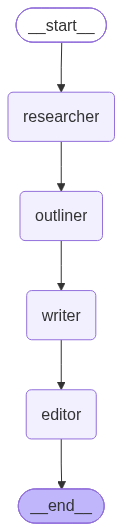

In [8]:
from IPython.display import Image, display

try:
    display(Image(blog_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running the pipeline end to end

A real topic, run through all four agents, with every intermediate artifact printed so
the hand-off between agents is visible.


In [9]:
topic = "Why vector databases matter for retrieval-augmented generation (RAG)"

result = blog_pipeline.invoke({"topic": topic})

print("=" * 70)
print("STAGE 1 -- research_notes (from researcher)")
print("=" * 70)
print(result["research_notes"])


STAGE 1 -- research_notes (from researcher)
- **Definition of Vector Databases**: Vector databases store data in high-dimensional vector spaces, allowing for efficient similarity searches, which is crucial for retrieving relevant information in RAG systems.

- **RAG Overview**: Retrieval-Augmented Generation combines traditional language models with a retrieval mechanism to enhance the generation of responses by providing contextually relevant information from external sources.

- **Efficiency in Search**: Vector databases utilize techniques like Approximate Nearest Neighbor (ANN) search, enabling rapid retrieval of relevant documents or data points, significantly reducing latency in RAG applications.

- **Semantic Understanding**: Unlike traditional keyword-based searches, vector databases leverage embeddings (e.g., from models like BERT or GPT) to understand semantic relationships, improving the relevance of retrieved information.

- **Scalability**: Vector databases are designed to 

In [10]:
print("=" * 70)
print("STAGE 2 -- outline (from outliner)")
print("=" * 70)
print(result["outline"])


STAGE 2 -- outline (from outliner)
# Working Title: The Importance of Vector Databases in Retrieval-Augmented Generation (RAG)

## I. Introduction to Vector Databases
- Definition of vector databases and their function in storing data in high-dimensional vector spaces.
- Importance of efficient similarity searches for RAG systems.

## II. Understanding Retrieval-Augmented Generation (RAG)
- Overview of RAG and its integration of traditional language models with retrieval mechanisms.
- The role of external sources in enhancing response generation through contextually relevant information.

## III. Efficiency and Performance in RAG Applications
- Techniques such as Approximate Nearest Neighbor (ANN) search that enable rapid data retrieval.
- Impact of reduced latency on the overall performance of RAG systems.

## IV. Semantic Understanding and Relevance
- Comparison of vector databases with traditional keyword-based search methods.
- Use of embeddings from models like BERT or GPT to impr

In [11]:
print("=" * 70)
print("STAGE 3 -- draft (from writer)")
print("=" * 70)
print(result["draft"])


STAGE 3 -- draft (from writer)
# The Importance of Vector Databases in Retrieval-Augmented Generation (RAG)

## I. Introduction to Vector Databases
Vector databases are specialized systems designed to store data in high-dimensional vector spaces. This unique structure allows for efficient similarity searches, which are crucial for the functionality of Retrieval-Augmented Generation (RAG) systems. By representing data points as vectors, these databases enable quick identification of similar items, enhancing the retrieval process that RAG relies upon to generate contextually relevant responses.

## II. Understanding Retrieval-Augmented Generation (RAG)
Retrieval-Augmented Generation (RAG) is an innovative approach that combines traditional language models with retrieval mechanisms. This integration allows RAG systems to enhance their response generation capabilities by utilizing external sources of information. By retrieving contextually relevant data, RAG can produce more accurate and i

In [12]:
print("=" * 70)
print("STAGE 4 -- final_post (from editor)")
print("=" * 70)
print(result["final_post"])


STAGE 4 -- final_post (from editor)
# Why Vector Databases Are Essential for Retrieval-Augmented Generation (RAG)

## I. Introduction to Vector Databases
Vector databases are specialized systems designed to store data in high-dimensional vector spaces. This structure allows for efficient similarity searches, which are crucial for the functionality of Retrieval-Augmented Generation (RAG) systems. By representing data points as vectors, these databases enable the quick identification of similar items, enhancing the retrieval process that RAG relies on to generate contextually relevant responses.

## II. Understanding Retrieval-Augmented Generation (RAG)
Retrieval-Augmented Generation (RAG) is an innovative approach that combines traditional language models with retrieval mechanisms. This integration enhances response generation capabilities by utilizing external sources of information. By retrieving contextually relevant data, RAG can produce more accurate and informative outputs, signif

**Expected output**: four visibly distinct pieces of text, each shaped by its stage's
narrow job -- terse bullet notes from the researcher, a headings-and-bullets outline
from the outliner, full but unpolished prose from the writer, and a tightened,
publish-ready post from the editor. The editor's output should follow the outliner's
structure (same section order) while reading more smoothly than the writer's raw draft.

## Common mistakes

- **One system message trying to do all four jobs.** If you write a single "you are a
  blog-writing assistant that researches, outlines, drafts, and edits" prompt, the model
  tends to skip stages under time/token pressure (jumping straight to a draft without
  real research) -- the whole point of splitting into four agents is that each one has a
  narrow enough job that skipping is obvious and each stage is individually inspectable.
- **Letting a later stage silently overwrite an earlier stage's field.** This notebook's
  `BlogState` keeps `research_notes`, `outline`, `draft`, and `final_post` as separate
  keys precisely so nothing is lost -- if the editor's node returned `{"draft":
  response.content}` instead of `{"final_post": ...}`, you'd lose the pre-edit draft and
  be unable to audit what the editor actually changed.
- **Passing the full outline text back to the researcher, or vice versa.** Each node
  only reads the state keys its own job needs (the researcher never sees `outline`; the
  outliner never sees `draft`) -- feeding later-stage content back to an earlier agent
  invites it to silently redo another agent's job.
- **Reaching for parallel/`Send` here.** These four stages are not independent -- see
  `parallel_fanout_fanin_orchestrator.ipynb` for what genuinely-independent parallel
  work looks like, and why fan-out would break this pipeline's dependency chain.

## Explain like I'm 12

Imagine writing a school report as an assembly line instead of alone. One friend only
looks up facts and hands you a note. A second friend only turns that note into a list of
sections. A third friend only writes full sentences for each section on the list. A
fourth friend only reads it over and fixes any clunky sentences before it's turned in.
Nobody skips ahead to writing sentences before there's a list of sections, and nobody
does two jobs at once -- each friend does exactly one thing, passes it to the next
friend, and that's the whole report built.

## Explain for interview

"A sequential multi-agent pipeline decomposes a task into stages with a genuine data
dependency -- stage *N* requires stage *N-1*'s output, not just its own subtask. Each
stage is a separate agent with its own narrow system message, so responsibilities don't
blur and every intermediate artifact is inspectable. This differs from a single agent
with one system message (which can silently skip or merge stages) and from parallel
fan-out (which is only correct when branches are independent of each other -- here they
are not: outlining needs research, drafting needs the outline)."

## Checkpoint questions

1. **Q: Why can't `outliner` and `writer` run in parallel here?**
   A: `writer` needs `outline` as input, and `outline` doesn't exist until `outliner`
   finishes -- a genuine data dependency, not just a scheduling choice.

2. **Q: What would go wrong if all four jobs shared one system message?**
   A: The model would have to juggle four sets of instructions at once and nothing
   would force it to actually produce research before drafting -- stages could be
   skipped or blurred together, and there'd be no separate `research_notes` /
   `outline` / `draft` artifacts to audit.

3. **Q: Why does `BlogState` keep `research_notes`, `outline`, and `draft` instead of
   only `final_post`?**
   A: So the pipeline is auditable -- you can inspect what each agent actually produced
   at each stage, not just trust the final output.

4. **Q: What's the topology difference between this notebook and
   `parallel_fanout_fanin_orchestrator.ipynb`?**
   A: This one is a single forward chain (`A -> B -> C -> D`) where each stage depends
   on the previous one's output; the fan-out/fan-in notebook dispatches to independent
   branches that run concurrently and only converge at the end, because those branches
   don't depend on each other.
